In [ ]:
%pip install yfinance keras seaborn scikit-learn tensorflow

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import keras


In [ ]:
# avoid laptop overheating. If a given laptop doesn't overheat, these lines can be removed/commented out
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

In [4]:
sp500 = yf.download(
    "^GSPC",
    start="1994-01-01",
    end="2025-06-20",
    interval="1d",
    progress=False
)

sp500.head()

YF.download() has changed argument auto_adjust default to True


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
1994-01-03,465.440002,466.940002,464.359985,466.510010,270140000
1994-01-04,466.890015,466.890015,464.440002,465.440002,326600000
1994-01-05,467.549988,467.820007,465.920013,466.890015,400030000
1994-01-06,467.119995,469.000000,467.019989,467.549988,365960000
1994-01-07,469.899994,470.260010,467.029999,467.089996,324920000


In [5]:
configs = [
    {
        "sequence_length": 21,  # number of days used to predict future prices
        "epochs": 1000,
        "batch_size": 32,
        "target_horizon": 5,
        "optim_params": {
            "lr": 0.001,
            "weight_decay": 1e-3,
        },
        "n_runs": 3,
        "scaling": 'standard',
        "params": {
            "hidden_sizes": [64, 64],
            "dropouts": [0.4, 0.4],
        },
        "use_bidirectional_lstm": True,
        "use_batch_norm": False,
        "relu_layer_size": None,  # can be None
        "dropout_relu_layer": None,  # can be None
        "exclude_features": ["price_to_sma_5"],
        "lstm_params": {
            "activation": "relu",
            "recurrent_activation": "sigmoid",
        },
    },
]

configs = {str(i): config for i, config in enumerate(configs)}

In [6]:
data = sp500[['Open', 'Close', 'High', 'Low', 'Volume']].copy()
data.columns = data.columns.get_level_values(0)

In [7]:
save_dir = Path("models")
save_dir.mkdir(parents=True, exist_ok=True)

preds_dir = Path("predictions")
preds_dir.mkdir(parents=True, exist_ok=True)

In [8]:
def build_model(config, feature_cols):
    def add_lstm(size, return_sequences, is_bidirectional, input_shape=None):
        if is_bidirectional:
            if input_shape:
                return Bidirectional(LSTM(size, return_sequences=return_sequences, input_shape=input_shape, activation=config["lstm_params"]["activation"], recurrent_activation=config["lstm_params"]["recurrent_activation"]))
            else:
                return Bidirectional(LSTM(size, return_sequences=return_sequences, activation=config["lstm_params"]["activation"], recurrent_activation=config["lstm_params"]["recurrent_activation"]))
        else:
            if input_shape:
                return LSTM(size, return_sequences=return_sequences, input_shape=input_shape, activation=config["lstm_params"]["activation"], recurrent_activation=config["lstm_params"]["recurrent_activation"])
            else:
                return LSTM(size, return_sequences=return_sequences, activation=config["lstm_params"]["activation"], recurrent_activation=config["lstm_params"]["recurrent_activation"])

    model = Sequential()
    if len(config["params"]["hidden_sizes"]) > 1:
        if "convdropout" in config["params"] and 0 < config["params"]["convdropout"] < 1:
            model.add(Dropout(config["params"]["convdropout"], input_shape=(config["sequence_length"], len(feature_cols))))
            model.add(add_lstm(config["params"]["hidden_sizes"][0], return_sequences=True, is_bidirectional=config["use_bidirectional_lstm"]))
        else:
            model.add(add_lstm(config["params"]["hidden_sizes"][0], return_sequences=True, input_shape=(config["sequence_length"], len(feature_cols)), is_bidirectional=config["use_bidirectional_lstm"]))
        if "use_batch_norm" in config and config["use_batch_norm"]:
            model.add(BatchNormalization())
        if "dropouts" in config["params"] and len(config["params"]["dropouts"]) and 0 < config["params"]["dropouts"][0] < 1:
            model.add(Dropout(config["params"]["dropouts"][0]))
        for i, hidden_size in enumerate(config["params"]["hidden_sizes"][1:-1]):
            model.add(add_lstm(hidden_size, return_sequences=True, is_bidirectional=config["use_bidirectional_lstm"]))
            if "use_batch_norm" in config and config["use_batch_norm"]:
                model.add(BatchNormalization())
            if "dropouts" in config["params"] and len(config["params"]["dropouts"]) <= i and 0 < config["params"]["dropouts"][i] < 1:
                model.add(Dropout(config["params"]["dropouts"][i]))
        model.add(add_lstm(config["params"]["hidden_sizes"][-1], return_sequences=False, is_bidirectional=config["use_bidirectional_lstm"]))
        if "use_batch_norm" in config and config["use_batch_norm"]:
            model.add(BatchNormalization())
        if "dropouts" in config["params"] and len(config["params"]["dropouts"]) <= len(config["params"]["hidden_sizes"]) and 0 < config["params"]["dropouts"][-1] < 1:
            model.add(Dropout(config["params"]["dropouts"][-1]))
    else:
        if "convdropout" in config["params"] and 0 < config["params"]["convdropout"] < 1:
            model.add(Dropout(config["params"]["convdropout"], input_shape=(config["sequence_length"], len(feature_cols))))
            model.add(add_lstm(config["params"]["hidden_sizes"][0], return_sequences=False, is_bidirectional=config["use_bidirectional_lstm"]))
        else:
            model.add(add_lstm(config["params"]["hidden_sizes"][0], return_sequences=False, input_shape=(config["sequence_length"], 1), is_bidirectional=config["use_bidirectional_lstm"]))
        if "use_batch_norm" in config and config["use_batch_norm"]:
            model.add(BatchNormalization())
        if "dropouts" in config["params"] and len(config["params"]["dropouts"]) and 0 < config["params"]["dropouts"][0] < 1:
            model.add(Dropout(config["params"]["dropouts"][0]))
    if "relu_layer_size" in config and config["relu_layer_size"] is not None and config["relu_layer_size"] > 1:
        model.add(Dense(config["relu_layer_size"], activation='relu'))
        if "use_batch_norm" in config and config["use_batch_norm"]:
            model.add(BatchNormalization())
        if "dropout_relu_layer" in config and config["dropout_relu_layer"] is not None and 0 < config["dropout_relu_layer"] < 1:
            model.add(Dropout(config["dropout_relu_layer"]))
    model.add(Dense(1))

    if "weight_decay" in config["optim_params"]:
        optimizer = keras.optimizers.Adam(learning_rate=config["optim_params"]["lr"], weight_decay=config["optim_params"]["weight_decay"])
    else:
        optimizer = keras.optimizers.Adam(learning_rate=config["optim_params"]["lr"])

    def huber_loss(y_true, y_pred, delta=1.0):
        error = y_true - y_pred
        cond = tf.abs(error) < delta
        return tf.where(cond, 0.5*tf.square(error), delta*(tf.abs(error)-0.5*delta))

    model.compile(loss=huber_loss, optimizer=optimizer)

    print(model.summary())

    return model

In [9]:
def add_features(df, target_horizon):
    df = df.copy()

    # Basic returns
    df['log_ret'] = np.log(df['Close']).diff()
    df['ret_squared'] = df['log_ret'] ** 2

    # Target feature
    df[f"target_rv"] = (
        df["log_ret"]
        .rolling(target_horizon)
        .std()
        .shift(-target_horizon)
        * np.sqrt(252)
    )

    # Realized volatility at multiple horizons
    for period in [3, 5, 10, 20]:
        df[f'rv_{period}d'] = df['log_ret'].rolling(period).std() * np.sqrt(252)
        df[f'rv_squared_{period}d'] = df['ret_squared'].rolling(period).mean() * 252

    # GARCH-style features
    df['ewm_vol_short'] = df['log_ret'].ewm(span=10).std() * np.sqrt(252)
    df['ewm_vol_long'] = df['log_ret'].ewm(span=30).std() * np.sqrt(252)
    df['vol_ratio'] = df['ewm_vol_short'] / df['ewm_vol_long']

    # # Higher moments
    # for period in [5, 10, 20]:
    #     df[f'skewness_{period}d'] = df['log_ret'].rolling(period).skew()
    #     df[f'kurtosis_{period}d'] = df['log_ret'].rolling(period).kurt()

    # Range-based volatility (Parkinson, Garman-Klass)
    df['garman_klass_vol'] = np.sqrt(
        0.5 * (np.log(df['High']/df['Low']))**2 -
        (2*np.log(2)-1) * (np.log(df['Close']/df['Open']))**2
    ) * np.sqrt(252)
    # df['parkinson_vol'] = np.sqrt(np.log(df['High']/df['Low'])**2 / (4*np.log(2))) * np.sqrt(252)

    # Volume features
    df['volume_ma'] = df['Volume'].rolling(20).mean()
    df['volume_ratio'] = df['Volume'] / df['volume_ma']
    df['volume_vol'] = df['Volume'].rolling(20).std() / df['volume_ma']
    df['log_volume'] = np.log(df['Volume'])
    df["log_volume"] = df["log_volume"].replace([np.inf, -np.inf], np.nan)
    # df['volume_ret'] = df['log_volume'].diff()

    # Price momentum and trend features
    for period in [5, 10, 20]:
        df[f'momentum_{period}d'] = df['Close'].pct_change(period)
        df[f'sma_{period}'] = df['Close'].rolling(period).mean()
        df[f'price_to_sma_{period}'] = df['Close'] / df[f'sma_{period}']

    # Intraday features
    df['oc_ratio'] = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1)
    df['hl_ratio'] = (df['High'] - df['Low']) / df['Close']

    # Gap indicators
    df['gap_up'] = ((df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1) > 0.01).astype(int)
    df['gap_down'] = ((df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1) < -0.01).astype(int)

    # Volatility clustering features
    df['vol_persistence'] = df['rv_5d'] / df['rv_20d']
    df['vol_change'] = df['rv_5d'].diff()
    df['vol_acceleration'] = df['vol_change'].diff()

    # # Regime features
    # df['trend_5d'] = (df['Close'] / df['Close'].shift(5) - 1)
    # df['trend_20d'] = (df['Close'] / df['Close'].shift(20) - 1)
    # df['drawdown'] = (df['Close'] / df['Close'].rolling(252).max() - 1)

    # # Calendar effects
    # df['month'] = df.index.month
    # df['day_of_week'] = df.index.dayofweek
    # df['is_month_end'] = (df.index == df.index + pd.offsets.MonthEnd(0)).astype(int)
    # df['is_quarter_end'] = df.index.month.isin([3, 6, 9, 12]).astype(int)

    # # Cyclical encoding for calendar features
    # df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    # df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    # df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    # df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    return df


In [10]:
val_end = pd.to_datetime("2024-03-01")
train_end = pd.to_datetime("2021-03-01")

/Users/vitto/university/WUTIS/Butterflies-/venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Correlation of features with the target variable:
Price
target_rv           1.000000
ewm_vol_short       0.698110
rv_10d              0.688955
ewm_vol_long        0.675960
rv_20d              0.661363
rv_5d               0.653601
garman_klass_vol    0.647843
hl_ratio            0.640257
rv_squared_10d      0.634435
rv_squared_5d       0.615063
rv_squared_20d      0.602229
rv_3d               0.584666
vol_ratio           0.221521
gap_down            0.182389
volume_vol          0.172190
vol_persistence     0.130351
volume_ratio        0.112910
gap_up              0.100788
vol_change          0.025234
vol_acceleration   -0.003564
oc_ratio           -0.119676
price_to_sma_5     -0.270870
momentum_5d        -0.292746
price_to_sma_10    -0.364035
momentum_10d       -0.388247
momentum_20d       -0.450082
price_to_sma_20    -0.456995
Name: target_rv, dtype: float64


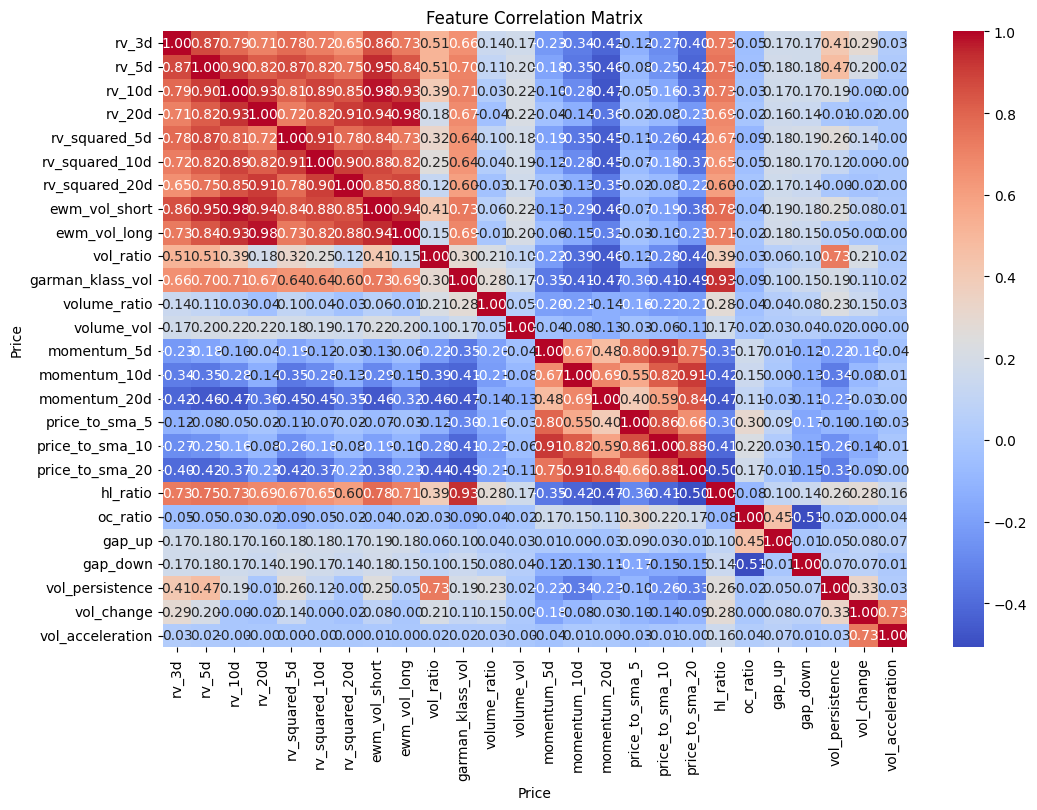

Training: 0

Run 1/3


/Users/vitto/university/WUTIS/Butterflies-/venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/1000
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.0116 - val_loss: 0.0032
Epoch 2/1000
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0098 - val_loss: 0.0039
Epoch 3/1000
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0055 - val_loss: 0.0042
Epoch 4/1000
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0045 - val_loss: 0.0024
Epoch 5/1000
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0035 - val_loss: 0.0031
Epoch 6/1000
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0028 - val_loss: 0.0024
Epoch 7/1000
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 8/1000
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0026 - val_loss: 0.0025
Epoch 9/1000
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 10/1000
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0026 - val_loss: 0.0033
Epoch 11/1000
213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0026 - val_loss: 0.0031
Epoch 12/1000


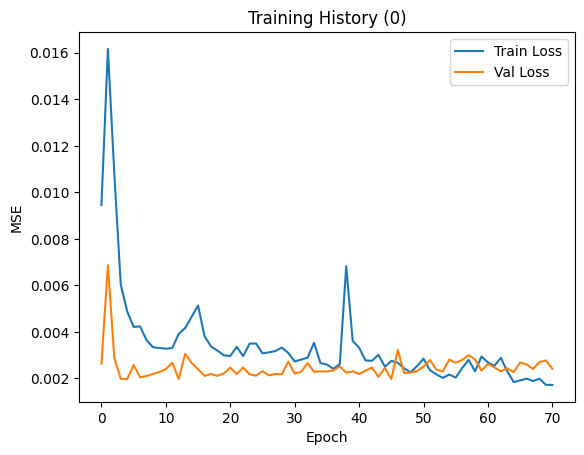

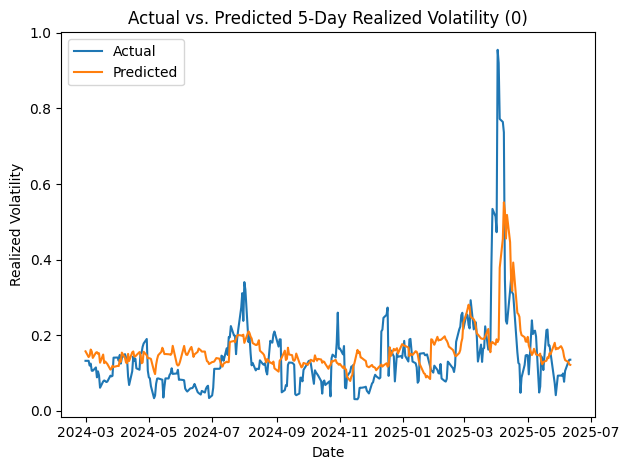

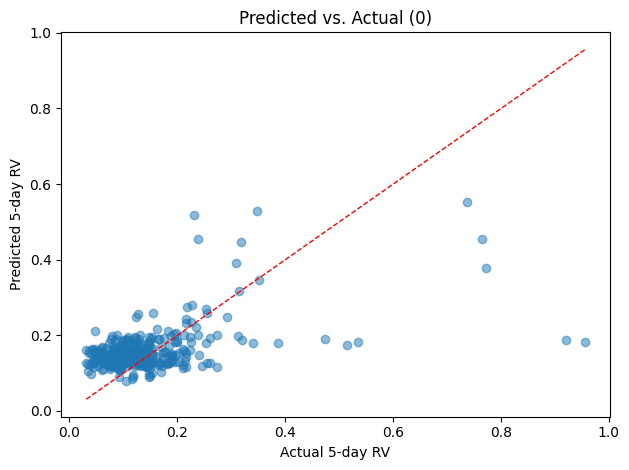

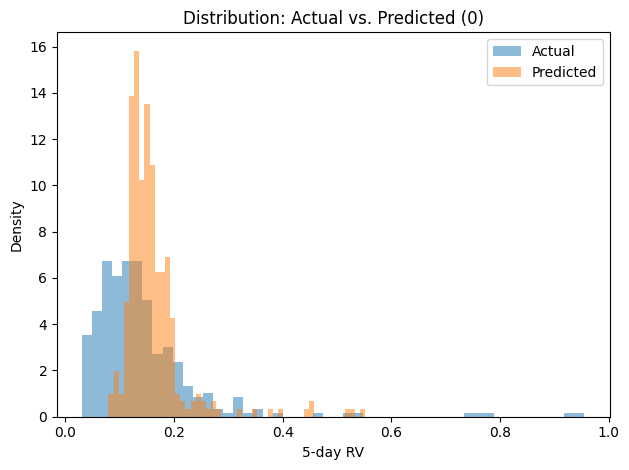

In [11]:
currdata = data.copy()

currdata = add_features(currdata, configs['0']["target_horizon"])
currdata = currdata.dropna()

feature_cols = [
    # Realized volatility features
    'rv_3d', 'rv_5d', 'rv_10d', 'rv_20d',
    # 'rv_3d', 'rv_5d', 'rv_10d', 'rv_20d',
    'rv_squared_5d', 'rv_squared_10d', 'rv_squared_20d',

    # GARCH-style features
    'ewm_vol_short', 'ewm_vol_long', 'vol_ratio',

    # Range-based volatility
    'garman_klass_vol',
    # 'parkinson_vol', 'garman_klass_vol',

    # # Higher moments
    # 'skewness_10d', 'kurtosis_10d',
    # 'skewness_20d', 'kurtosis_20d',
    # 'skewness_5d', 'kurtosis_5d',

    # Volume features
    'volume_ratio', 'volume_vol',
    # 'volume_ratio', 'volume_vol', 'volume_ret',

    # Price momentum
    'momentum_5d', 'momentum_10d', 'momentum_20d',
    'price_to_sma_5', 'price_to_sma_10', 'price_to_sma_20',

    # Intraday features
    # 'oc_ratio',
    'hl_ratio', 'oc_ratio',
    'gap_up', 'gap_down',

    # Volatility clustering
    # 'vol_persistence',
    'vol_persistence', 'vol_change', 'vol_acceleration',
]
print("Correlation of features with the target variable:")  # NOTE: could drop those that are not that correlated, eg. between -0.1 and 0.1
print(currdata[feature_cols + ["target_rv"]].corr()[f"target_rv"].sort_values(ascending=False))
# Plot a heatmap to visualize the correlations. NOTE: could drop features that are highly correlated between each other, eg. > 0.8 or < -0.8
feature_corr = currdata[feature_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(feature_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

for name, config in configs.items():
    print("Training:", name)

    X = []
    y = []

    config_feature_cols = [col for col in feature_cols if col not in config["exclude_features"]]

    if "scaling" in config and config["scaling"] == 'minmax':
      scaler = MinMaxScaler()
      features = scaler.fit_transform(currdata[config_feature_cols])
    elif "scaling" in config and config["scaling"] == 'standard':
      scaler = StandardScaler()
      features = scaler.fit_transform(currdata[config_feature_cols])
    else:
      features = currdata[config_feature_cols].values

    target_values = currdata[f"target_rv"].values
    for i in range(config["sequence_length"], len(currdata)):
        X.append(features[i-config["sequence_length"]:i])
        y.append(target_values[i])
    X = np.array(X)
    y = np.array(y).reshape(-1, 1)

    sample_dates = currdata.index[config["sequence_length"]:]

    mask_train = sample_dates < train_end
    mask_val   = (sample_dates >= train_end) & (sample_dates < val_end)
    mask_test  = sample_dates >= val_end

    X_train = X[mask_train]
    X_val   = X[mask_val]
    X_test  = X[mask_test]

    y_train = y[mask_train]
    y_val   = y[mask_val]
    y_test  = y[mask_test]

    best_model = None
    best_val_rmse = float('inf')
    best_run = -1
    all_results = []

    for run in range(config["n_runs"]):
        print(f"\nRun {run + 1}/{config['n_runs']}")

        model = build_model(config, config_feature_cols)
        tf.keras.utils.set_random_seed(42 + run)

        es = EarlyStopping(
            monitor="val_loss",
            start_from_epoch=25,
            patience=25,
            restore_best_weights=True,
            min_delta=1e-6
        )
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=config["epochs"],
            batch_size=config["batch_size"],
            callbacks=[es],
            shuffle=False,
        )

        min_val_loss = min(history.history['val_loss'])

        y_pred = model.predict(X_val)
        rmse = np.sqrt(np.mean((y_pred.flatten() - y_val.flatten())**2))
        print(f"Run {run + 1} - Min Val Loss: {min_val_loss:.6f}, Val RMSE: {rmse:.4f}")

        all_results.append({
            'run': run + 1,
            'val_loss': min_val_loss,
            'test_rmse': rmse,
            'epochs_trained': len(history.history['loss'])
        })

        if rmse < best_val_rmse:
            best_val_rmse = rmse
            best_model = model
            best_run = run + 1
            best_history = history
            print(f"*** New best model found! (Run {best_run}) ***")

    final_pred = best_model.predict(X_test, verbose=0)
    final_rmse = np.sqrt(np.mean((final_pred.flatten() - y_test.flatten())**2))
    final_mae = mean_absolute_error(y_test.flatten(), final_pred.flatten())

    print(f"\nFINAL RESULTS (Best Model - Run {best_run}):")
    print(f"Test RMSE ({config['target_horizon']}-day rv): {final_rmse:.4f}")
    print(f"Test MAE ({config['target_horizon']}-day rv): {final_mae:.4f}")

    model_path = save_dir / f"demo3_{name}.keras"
    model.save(model_path)

    temp_sample_dates = currdata.index
    mask_future = temp_sample_dates >= val_end
    dates = currdata.loc[mask_future].index

    df = pd.DataFrame({
        'predicted_vola': final_pred[:, 0][:-5],
        'prediction_day': dates[:-5],
        'predicted_day': dates[5:]
    }).to_csv(f'{preds_dir}/demo3_{name}.csv')

    plt.figure()
    plt.plot(best_history.history["loss"], label="Train Loss")
    plt.plot(best_history.history["val_loss"], label="Val Loss")
    plt.title(f"Training History ({name})")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.show()

    dates_test = sample_dates[mask_test]
    y_true_plot = y_test.flatten()
    y_pred_plot = final_pred.flatten()
    plt.figure()
    plt.plot(dates_test, y_true_plot, label="Actual")
    plt.plot(dates_test, y_pred_plot, label="Predicted")
    plt.title(f"Actual vs. Predicted {config['target_horizon']}-Day Realized Volatility ({name})")
    plt.xlabel("Date")
    plt.ylabel("Realized Volatility")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.scatter(y_true_plot, y_pred_plot, alpha=0.5)
    plt.plot([y_true_plot.min(), y_true_plot.max()],
            [y_true_plot.min(), y_true_plot.max()],
            'r--', linewidth=1)
    plt.xlabel(f"Actual {config['target_horizon']}-day RV")
    plt.ylabel(f"Predicted {config['target_horizon']}-day RV")
    plt.title(f"Predicted vs. Actual ({name})")
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.hist(y_true_plot, bins=50, alpha=0.5, label="Actual", density=True)
    plt.hist(y_pred_plot, bins=50, alpha=0.5, label="Predicted", density=True)
    plt.xlabel(f"{config['target_horizon']}-day RV")
    plt.ylabel("Density")
    plt.title(f"Distribution: Actual vs. Predicted ({name})")
    plt.legend()
    plt.tight_layout()
    plt.show()
